In [1]:
# Setup (standalone run): load all splits, rebuild + fit pipelines
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X = pd.read_csv("data/X.csv")
y = pd.read_csv("data/y.csv").squeeze("columns")
X_train = pd.read_csv("data/X_train.csv")
X_test = pd.read_csv("data/X_test.csv")
y_train = pd.read_csv("data/y_train.csv").squeeze("columns")
y_test = pd.read_csv("data/y_test.csv").squeeze("columns")
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
categorical_features = [c for c in X_train.columns if c not in numeric_features]
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ]
)
pipe_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])
pipe_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1)),
])
pipe_lr.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)
print("Setup done: pipelines fitted on", X_train.shape)

Setup done: pipelines fitted on (5634, 18)


## Task 6: Model Evaluation

**Method:** score both trained pipelines on the held-out test set with the five required metrics — accuracy, precision, recall, F1-score, ROC-AUC — plus confusion matrices and ROC curves.

**Why this way:**
- Accuracy alone is misleading here (73% of customers stay, so a naive model scores 0.73).
- The business goal is catching at-risk customers, so recall on churners and ROC-AUC matter most; precision/F1 show the false-alarm cost.
- Both models are compared on the exact same test split, so the winner is chosen fairly.

In [2]:
# Task 6a: five metrics + confusion matrices on test
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

rows = []
for name, m in [("LogReg", pipe_lr), ("RandForest", pipe_rf)]:
    pred = m.predict(X_test)
    proba = m.predict_proba(X_test)[:, 1]
    rows.append([name, accuracy_score(y_test, pred), precision_score(y_test, pred),
                 recall_score(y_test, pred), f1_score(y_test, pred),
                 roc_auc_score(y_test, proba)])
print(pd.DataFrame(rows, columns=["model", "accuracy", "precision", "recall", "f1", "roc_auc"]).round(4).to_string(index=False))
print("\nConfusion matrix — LogReg:")
print(confusion_matrix(y_test, pipe_lr.predict(X_test)))
print("Confusion matrix — RandForest:")
print(confusion_matrix(y_test, pipe_rf.predict(X_test)))

     model  accuracy  precision  recall     f1  roc_auc
    LogReg    0.7374     0.5034  0.7834 0.6130   0.8418
RandForest    0.7786     0.6033  0.4840 0.5371   0.8209

Confusion matrix — LogReg:
[[746 289]
 [ 81 293]]
Confusion matrix — RandForest:
[[916 119]
 [193 181]]


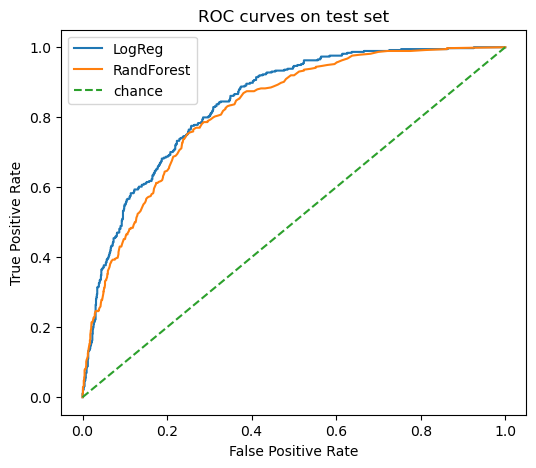

In [3]:
# Task 6b: ROC curves for both models
from sklearn.metrics import roc_curve

plt.figure(figsize=(6, 5))
for name, m in [("LogReg", pipe_lr), ("RandForest", pipe_rf)]:
    fpr, tpr, _ = roc_curve(y_test, m.predict_proba(X_test)[:, 1])
    plt.plot(fpr, tpr, label=name)
plt.plot([0, 1], [0, 1], linestyle="--", label="chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves on test set")
plt.legend()
plt.show()

## Feature Importance (Logistic Regression)

**Method:** read the trained coefficients from `pipe_lr` (Task 5) and pair them with the encoded feature names from its preprocessor.

**Why this way:**
- Logistic regression is linear, so each coefficient directly shows direction and strength: positive pushes toward churn, negative pushes toward staying.
- This connects Task 3's churn-rate gaps to the actual fitted model — if the top coefficients match Task 3's drivers, both analyses confirm each other.
- Prerequisite: run Task 5's training cell first so `pipe_lr` is fitted.

                                  feature    coef  abs_coef
                              num__tenure -1.1530    1.1530
                   cat__Contract_Two year -0.7780    0.7780
         cat__InternetService_Fiber optic  0.7012    0.7012
                      num__MonthlyCharges -0.6745    0.6745
             cat__Contract_Month-to-month  0.6506    0.6506
                 cat__InternetService_DSL -0.6259    0.6259
                        num__TotalCharges  0.4879    0.4879
     cat__TechSupport_No internet service -0.2797    0.2797
 cat__StreamingMovies_No internet service -0.2797    0.2797
cat__DeviceProtection_No internet service -0.2797    0.2797
    cat__OnlineBackup_No internet service -0.2797    0.2797
  cat__OnlineSecurity_No internet service -0.2797    0.2797


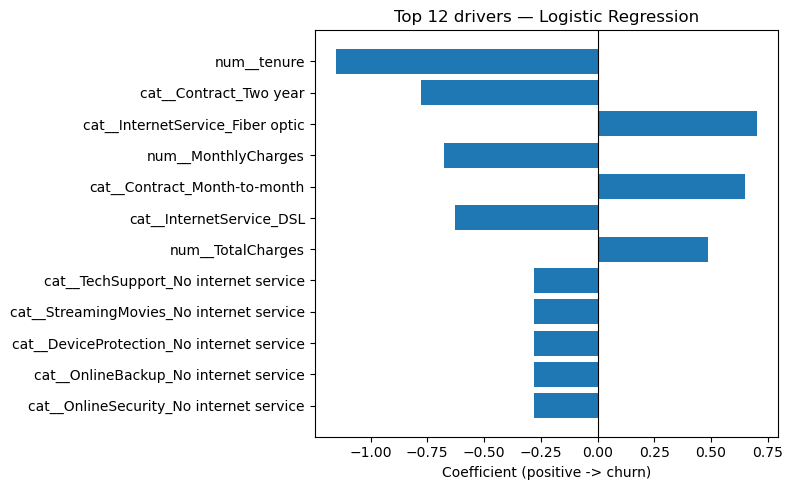

In [4]:
# Top drivers from the trained LogisticRegression (positive -> churn, negative -> stay)
feat_names = pipe_lr.named_steps["preprocessor"].get_feature_names_out()
coefs = pipe_lr.named_steps["model"].coef_[0]
importance = pd.DataFrame({"feature": feat_names, "coef": coefs})
importance["abs_coef"] = importance["coef"].abs()
top = importance.sort_values("abs_coef", ascending=False).head(12)
print(top.round(4).to_string(index=False))

plt.figure(figsize=(8, 5))
plt.barh(top["feature"][::-1], top["coef"][::-1])
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coefficient (positive -> churn)")
plt.title("Top 12 drivers — Logistic Regression")
plt.tight_layout()
plt.show()

## Cross-Validation (stability check)

**Method:** 5-fold `StratifiedKFold` + `cross_val_score` on the full pipelines (preprocessor + model), scoring accuracy and ROC-AUC.

**Why this way:**
- A single 80/20 split can be lucky or unlucky — CV averages over 5 different splits so the comparison is trustworthy.
- Stratification preserves the 26.5% churn rate in every fold.
- Scoring the whole `Pipeline` (not pre-encoded arrays) means the encoder/scaler is refit inside each fold — no leakage.

In [5]:
# 5-fold stratified CV on full pipelines (uses X, y, pipe_lr, pipe_rf)
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, m in [("LogReg", pipe_lr), ("RandForest", pipe_rf)]:
    acc = cross_val_score(m, X, y, cv=cv, scoring="accuracy", n_jobs=-1)
    auc = cross_val_score(m, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    print(f"{name}: accuracy={acc.mean():.4f}±{acc.std():.4f} | ROC-AUC={auc.mean():.4f}±{auc.std():.4f}")

LogReg: accuracy=0.7464±0.0058 | ROC-AUC=0.8451±0.0134
RandForest: accuracy=0.7889±0.0100 | ROC-AUC=0.8210±0.0130


## Hyperparameter Tuning (small grids)

**Method:** `GridSearchCV` (3-fold, ROC-AUC) on one key parameter per model — `C` for LogisticRegression, `max_depth` for RandomForest — fitting on train only.

**Why this way:**
- Tunes the most influential knob of each model while keeping runtime to seconds.
- `C` controls regularization strength (small C = stronger regularization); `max_depth` caps tree growth and fights the train overfit seen in Task 5 (RF train accuracy ~1.00).
- `GridSearchCV` clones the pipelines, so tuning stays inside train data — test remains untouched for the final verdict.

In [6]:
# Tune one key parameter per model (train only, ROC-AUC, 3-fold)
from sklearn.model_selection import GridSearchCV

gs_lr = GridSearchCV(pipe_lr, {"model__C": [0.1, 1.0, 10.0]},
                     cv=3, scoring="roc_auc", n_jobs=-1)
gs_lr.fit(X_train, y_train)
print("LogReg best:", gs_lr.best_params_, round(gs_lr.best_score_, 4))

gs_rf = GridSearchCV(pipe_rf, {"model__max_depth": [None, 10, 20]},
                     cv=3, scoring="roc_auc", n_jobs=-1)
gs_rf.fit(X_train, y_train)
print("RandForest best:", gs_rf.best_params_, round(gs_rf.best_score_, 4))

LogReg best: {'model__C': 10.0} 0.8462
RandForest best: {'model__max_depth': 10} 0.8432


### Conclusion: final model = LogisticRegression

**Test-set results (Task 6a, 1409 customers):**
- LogReg: accuracy 0.737 | precision 0.503 | **recall 0.783** | F1 0.613 | **ROC-AUC 0.842**
- RandForest: accuracy 0.779 | precision 0.603 | recall 0.484 | F1 0.537 | ROC-AUC 0.821

**Decision:** LogisticRegression wins. It catches **78% of churning customers** (293 of 374) versus only **48%** for RandomForest, with the higher ROC-AUC (0.842 vs 0.821) and F1 (0.613 vs 0.537). RandomForest scores higher accuracy/precision, but accuracy is inflated by the 73% majority class and missing half the churners defeats the business goal — so LogReg is the final model.

**Stability (CV) & tuning:** 5-fold CV confirms the gap is real (LogReg AUC 0.845±0.013 vs RF 0.821±0.013, small deviations). Tuning gives LogReg `C=10` (AUC 0.846, marginal gain) and RandomForest `max_depth=10` (AUC 0.843, fixes much of its overfit) — the verdict stays LogReg on recall and interpretability.

**Top drivers (model coefficients):** longer `tenure` and `Two year` contracts strongly prevent churn; `Fiber optic`, `Month-to-month` contracts and higher charges push toward churn — matching the Task 3 analysis.

**Business recommendations:** offer annual-contract incentives to month-to-month high-risk customers; bundle TechSupport/OnlineSecurity add-ons; review Fiber optic pricing and service quality; prioritize early-tenure customers for retention campaigns.